# XGBoost

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    RocCurveDisplay, precision_score, recall_score, f1_score
)
import xgboost as xgb
from xgboost import plot_importance

In [ ]:
# Load dataset
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")
display(df.head())
print(f"Dataset shape: {df.shape}")



,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-2.839944,-1.247643,1.014425,-0.339953,-1.099294,0.092576,0.517341,0.408477,-0.086671,-0.036771,0
1,-0.352317,1.434602,-0.451466,-0.359328,0.000225,-0.189705,-0.298579,-0.370672,-0.114527,0.056526,0
2,-2.088348,-0.190338,-1.506188,-1.079722,-0.208352,-0.238015,0.160883,-0.210342,0.153532,0.008629,1
3,-0.375654,1.872523,-0.302458,-0.423412,-0.256734,-0.361657,-0.244218,0.374798,0.185815,0.003063,0
4,-1.362409,-2.841712,0.577507,0.012427,0.531640,0.700028,0.178311,-0.106544,0.143042,-0.114418,1


Dataset shape: (7043, 11)


In [14]:
# Define features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train-Test Split (stratified due to potential class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Churn distribution in training set: {np.bincount(y_train)}")
print(f"Churn distribution in test set: {np.bincount(y_test)}")

# Dictionary to store comparison results
comparison = {}

Training set: (5634, 10), Test set: (1409, 10)
Churn distribution in training set: [4139 1495]
Churn distribution in test set: [1035  374]


#### PART 1: Basic XGBoost with Default Parameters (Baseline)


In [15]:
xgb1 = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Train the model
xgb1.fit(X_train, y_train)

# Predictions
y_pred1 = xgb1.predict(X_test)
y_pred_proba1 = xgb1.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:11:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# Evaluation metrics
acc1 = accuracy_score(y_test, y_pred1)
precision1 = precision_score(y_test, y_pred1)
recall1 = recall_score(y_test, y_pred1)
f1_1 = f1_score(y_test, y_pred1)

# Store results
comparison['XGBoost Baseline'] = {
    'accuracy': acc1,
    'precision': precision1,
    'recall': recall1,
    'f1_score': f1_1
}

print(f"Test Accuracy: {acc1:.4f}")
print(f"Precision: {precision1:.4f}")
print(f"Recall: {recall1:.4f}")
print(f"F1-Score: {f1_1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred1))

Test Accuracy: 0.7786
Precision: 0.6040
Recall: 0.4813
F1-Score: 0.5357

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.85      1035
           1       0.60      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



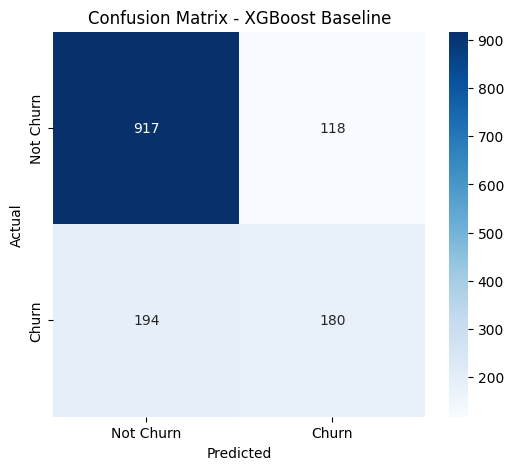

In [17]:
# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title("Confusion Matrix - XGBoost Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

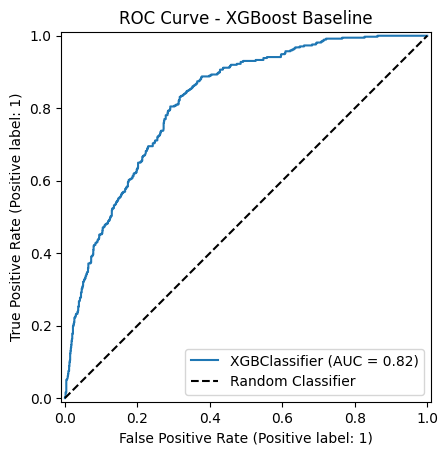

In [18]:
# ROC Curve
RocCurveDisplay.from_estimator(xgb1, X_test, y_test)
plt.title("ROC Curve - XGBoost Baseline")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

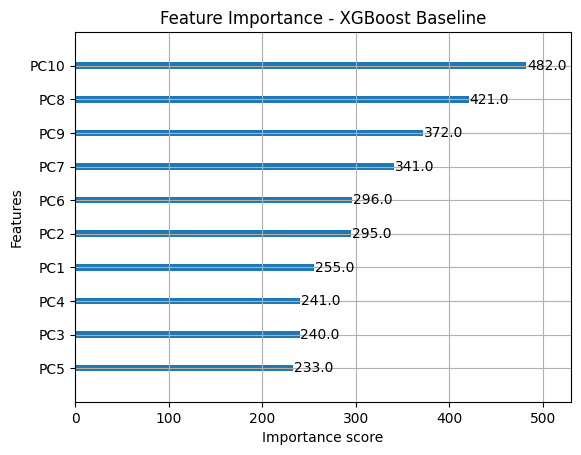

In [19]:
# Feature Importance
plt.figure(figsize=(10, 8))
plot_importance(xgb1, max_num_features=15)
plt.title("Feature Importance - XGBoost Baseline")
plt.show()

#### PART 2: XGBoost with Hyperparameter Tuning (GridSearchCV)


In [20]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb2 = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

In [21]:
# GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(
    xgb2, param_grid, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

# Best model
best_xgb2 = grid_search.best_estimator_
y_pred2 = best_xgb2.predict(X_test)
y_pred_proba2 = best_xgb2.predict_proba(X_test)[:, 1]

Fitting 5 folds for each of 81 candidates, totalling 405 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:15:35] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
# Evaluation metrics
acc2 = accuracy_score(y_test, y_pred2)
precision2 = precision_score(y_test, y_pred2)
recall2 = recall_score(y_test, y_pred2)
f1_2 = f1_score(y_test, y_pred2)

# Store results
comparison['XGBoost Tuned'] = {
    'accuracy': acc2,
    'precision': precision2,
    'recall': recall2,
    'f1_score': f1_2,
    'best_params': grid_search.best_params_
}

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {acc2:.4f}")
print(f"Precision: {precision2:.4f}")
print(f"Recall: {recall2:.4f}")
print(f"F1-Score: {f1_2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred2))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best Cross-Validation Score: 0.7977
Test Accuracy: 0.7942
Precision: 0.6419
Recall: 0.5080
F1-Score: 0.5672

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



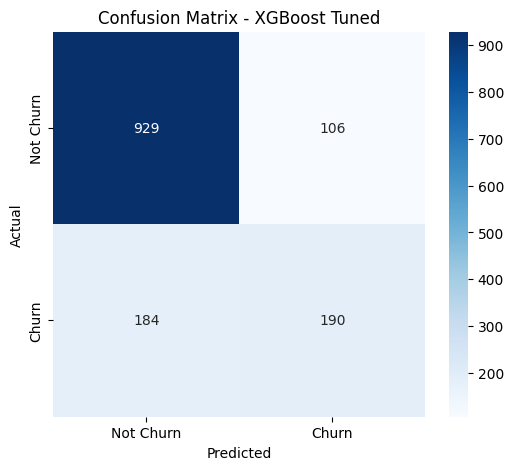

In [23]:
# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title("Confusion Matrix - XGBoost Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

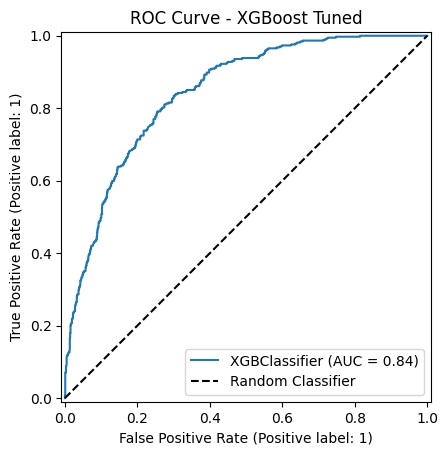

In [24]:
# ROC Curve
RocCurveDisplay.from_estimator(best_xgb2, X_test, y_test)
plt.title("ROC Curve - XGBoost Tuned")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

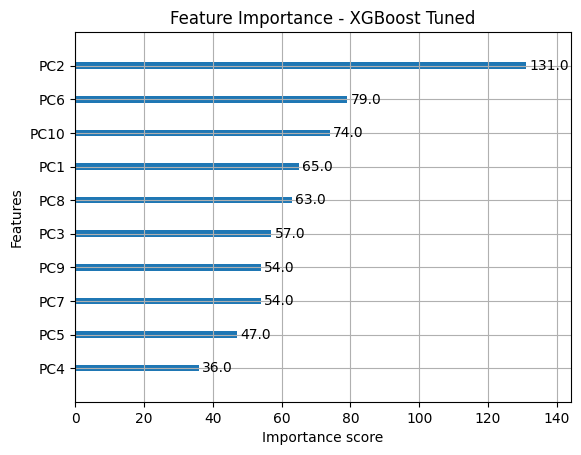

In [25]:
# Feature Importance for tuned model
plt.figure(figsize=(10, 8))
plot_importance(best_xgb2, max_num_features=15)
plt.title("Feature Importance - XGBoost Tuned")
plt.show()

#### PART 3: XGBoost with Class Weight Balancing


In [26]:
# Calculate scale_pos_weight for handling class imbalance
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Scale positive weight (for class imbalance): {scale_pos_weight:.2f}")

xgb3 = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9
)

# Train the model
xgb3.fit(X_train, y_train)

# Predictions
y_pred3 = xgb3.predict(X_test)
y_pred_proba3 = xgb3.predict_proba(X_test)[:, 1]

Scale positive weight (for class imbalance): 2.77


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:15:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
# Evaluation metrics
acc3 = accuracy_score(y_test, y_pred3)
precision3 = precision_score(y_test, y_pred3)
recall3 = recall_score(y_test, y_pred3)
f1_3 = f1_score(y_test, y_pred3)

# Store results
comparison['XGBoost Balanced'] = {
    'accuracy': acc3,
    'precision': precision3,
    'recall': recall3,
    'f1_score': f1_3
}

print(f"Test Accuracy: {acc3:.4f}")
print(f"Precision: {precision3:.4f}")
print(f"Recall: {recall3:.4f}")
print(f"F1-Score: {f1_3:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred3))

Test Accuracy: 0.7580
Precision: 0.5333
Recall: 0.7059
F1-Score: 0.6076

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.53      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



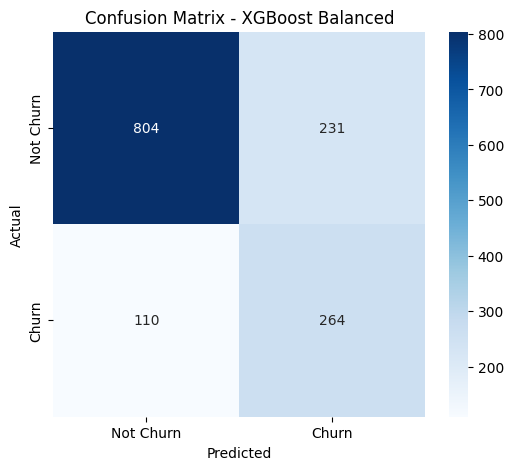

In [28]:
# Confusion Matrix
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.title("Confusion Matrix - XGBoost Balanced")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

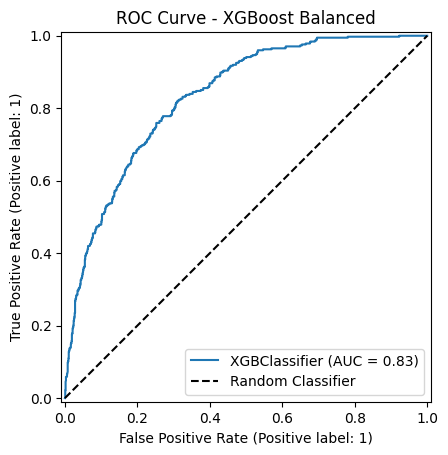

In [29]:
# ROC Curve
RocCurveDisplay.from_estimator(xgb3, X_test, y_test)
plt.title("ROC Curve - XGBoost Balanced")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

#### COMPARISON OF ALL XGBOOST MODELS


In [30]:
# Create comparison dataframe
comparison_data = []
for model_name, metrics in comparison.items():
    if 'best_params' in metrics:
        row = {
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score'],
            'Best Params': str(metrics['best_params'])[:50] + "..."  # Truncate for display
        }
    else:
        row = {
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'Precision': metrics['precision'],
            'Recall': metrics['recall'],
            'F1-Score': metrics['f1_score'],
            'Best Params': 'N/A'
        }
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by='F1-Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score,Best Params
2,XGBoost Balanced,0.757984,0.533333,0.705882,0.607595,N/A
1,XGBoost Tuned,0.794180,0.641892,0.508021,0.567164,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
0,XGBoost Baseline,0.778566,0.604027,0.481283,0.535714,N/A


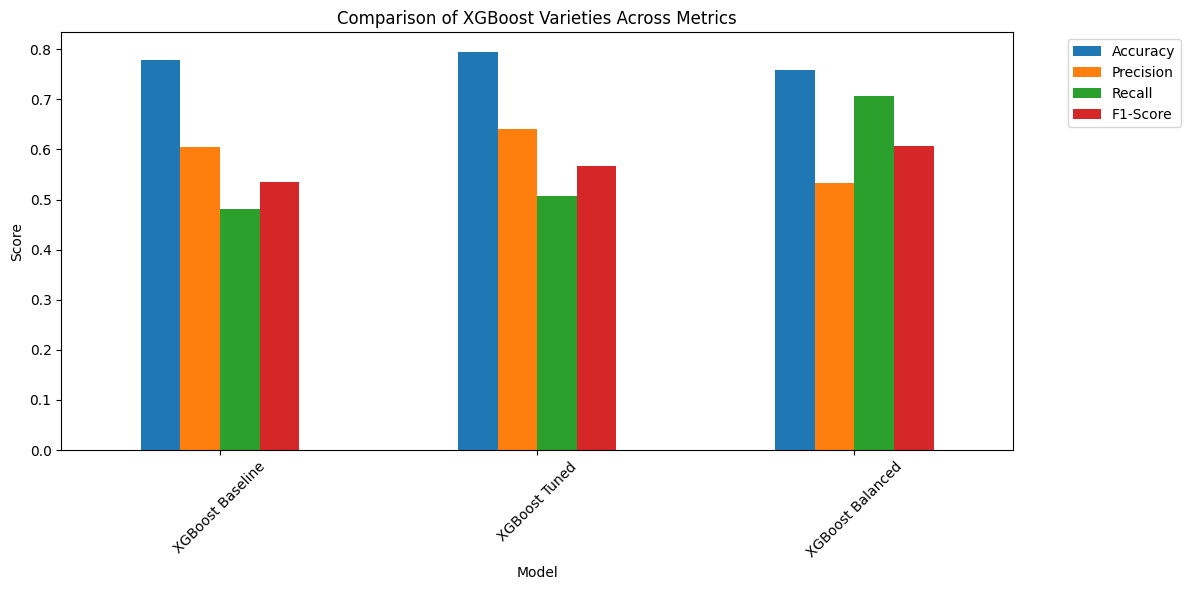

In [31]:
# Visual comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
comparison_df.set_index('Model')[metrics_to_plot].plot(kind='bar', figsize=(12, 6))
plt.title('Comparison of XGBoost Varieties Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [32]:
# Perform 5-fold cross-validation on the best model
cv_scores = cross_val_score(best_xgb2, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:16:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:16:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:16:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:16:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Cross-Validation Scores: [0.81898846 0.80035492 0.80301686 0.78704525 0.77886323]
Mean CV Accuracy: 0.7977 (+/- 0.0277)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [15:16:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
